# Лабораторна 1. Основні бібліотеки. Лінійні моделі навчання.

В цій лабораторній роботі студенти:
- ознайомлюються з сервісом Colab;
- ознайомлюються з базовими бібліотеками для машинного навчання;
- тренують неглибокі лінійні моделі машинного навчання на базі простих регресій: лінійна, логістична, поліноміальна.

## 0. Налаштування середовища

### 0.0. Імпортуємо залежності

In [ ]:
import sys
import os
import random
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

### 0.1. Перевіряємо чи ми точно в Colab

In [ ]:
IN_COLAB = "google.colab" in sys.modules
print("Running in Colab:", IN_COLAB)

assert IN_COLAB, f"Ця лаба має вокинуватися в Google Colab (https://colab.research.google.com/)"

Running in Colab: True


### 0.2. Фіксуємо всі джерела випадковості.
На GPU повна детермінованість трохи сповільнює тренування
(`cudnn.deterministic = True` вимикає частину швидких алгоритмів) —
тут це не критично, адже дані й модель дрібні.

In [ ]:
SEED = 42

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

**Вправа 1.** Скористайся вбудованим модулем `random`. Спробуй `random.randint(1, 100)` і `random.shuffle()` на списку — випадковість буває не лише в числі, а й у перестановці. Згенеруй обома способами двічі ДО виклику `set_seed()` — переконайся, що результати різні. Потім ще двічі **ПІСЛЯ** з викликом set_seed() після кожної генерації і потім ще двічі **без проміжного виклику** `set_seed()`.

Після клітинки з кодом створи клітинку з маркдауном і поясни що відбувається після `set_seed()` і як це проявляється в результатах виконання коду.

In [ ]:
numbers = list(range(10))  # список для shuffle

# TODO: двічі ДО set_seed() -- наприклад random.randint(1, 100) і random.shuffle(numbers)
print("ДО виклику set_seed()")
print("Генерація 1 (число):", random.randint(1, 100))
random.shuffle(numbers)
print("Генерація 1 (список):", numbers)

print("\nГенерація 2 (число):", random.randint(1, 100))
random.shuffle(numbers)
print("Генерація 2 (список):", numbers)

set_seed()
print("Seed зафіксовано:", SEED)

# TODO: тепер двічі ПІСЛЯ set_seed() -- виклич set_seed() перед КОЖНИМ окремим генеруванням
set_seed()
print("\n З постійним скиданням (set_seed перед генерацією)")
print("Генерація 3 (число):", random.randint(1, 100))
random.shuffle(numbers)
print("Генерація 3 (список):", numbers)

set_seed()
print("\nГенерація 4 (число):", random.randint(1, 100))
random.shuffle(numbers)
print("Генерація 4 (список):", numbers)

# TODO: тепер ще двічі без проміжних викликів set_seed()
print("\n БЕЗ проміжних викликів set_seed()")
print("Генерація 5 (число):", random.randint(1, 100))
random.shuffle(numbers)
print("Генерація 5 (список):", numbers)

print("\nГенерація 6 (число):", random.randint(1, 100))
random.shuffle(numbers)
print("Генерація 6 (список):", numbers)

ДО виклику set_seed()
Генерація 1 (число): 62
Генерація 1 (список): [7, 3, 1, 2, 4, 9, 0, 5, 6, 8]

Генерація 2 (число): 44
Генерація 2 (список): [9, 2, 3, 6, 8, 7, 4, 5, 0, 1]
Seed зафіксовано: 42

 З постійним скиданням (set_seed перед генерацією)
Генерація 3 (число): 82
Генерація 3 (список): [5, 6, 3, 0, 7, 4, 1, 8, 9, 2]

Генерація 4 (число): 82
Генерація 4 (список): [8, 0, 3, 9, 4, 1, 2, 7, 5, 6]

 БЕЗ проміжних викликів set_seed()
Генерація 5 (число): 76
Генерація 5 (список): [4, 9, 3, 6, 1, 0, 7, 5, 8, 2]

Генерація 6 (число): 92
Генерація 6 (список): [0, 9, 2, 4, 3, 1, 5, 6, 7, 8]


Пояснення до Вправи 1:

Комп'ютери використовують складні математичні формули для генерації псевдовипадкових чисел. Функція set_seed() фіксує початкову точку (зерно) для цих формул, роблячи результати відтворюваними.

Як це проявляється в результатах виконання коду:

До set_seed(): Генератор бере випадкову початкову точку, тому числа і перестановки завжди унікальні й непередбачувані.

З викликом set_seed() перед кожною генерацією: Ми примусово повертаємо генератор на стартову позицію. Через це генерується ідентичне число (82). Для списку генерується однакова послідовність перестановок. Проте, оскільки random.shuffle() змінює список "на місці", а ми не скидали сам список до початкового стану [0, 1, 2...], ці однакові перестановки застосовуються до вже перемішаного списку, даючи візуально інший результат.

Без проміжних викликів set_seed(): Генератор продовжує свою математичну послідовність далі, генеруючи нові числа. Але якщо перезапустити всю комірку з кодом спочатку, ці результати повторяться точнісінько так само, гарантуючи відтворюваність експерименту.

### 0.3. Використовуємо лише CPU (в цій лабі)
На Colab зазвичай є безкоштовний GPU (T4), але для лінійної регресії
на кількасот точок CPU часто не повільніший — виграш GPU з'їдає пересилання
даних на пристрій і назад щоепохи. Тому нижче свідомо тренуємось на CPU.

In [ ]:
device_available = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")

print("Доступний пристрій :", device_available)
print("Використовуємо     :", device)
if device_available.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

assert device.type == "cpu", f"Ця лаба має виконуватися на CPU, а не на GPU ({device})"

Доступний пристрій : cpu
Використовуємо     : cpu


**Вправа 2.** Встанови CPU рантайм. Запусти комірку вище і зроби скріншот виводу. Потім у Colab зміни рантайм на GPU, перезапусти всі комірки від початку. Знову зроби скріншот тієї самої комірки. Збережи обидва скріншоти — пізніше завантажиш їх на GitHub разом зі здачею лаби.

### 0.4. Монтуємо Google Drive

Сесія Colab обмежена в часі й може скинутись — усе в `/content` зникає разом
з нею. Монтуємо Drive, щоб чекпоінт моделі й логи TensorBoard пережили
перезапуск.

In [ ]:
from google.colab import drive
drive.mount("/content/drive")
ARTIFACT_DIR = "/content/drive/MyDrive/ai_systems/lab1"


os.makedirs(ARTIFACT_DIR, exist_ok=True)
RUNS_DIR = os.path.join(ARTIFACT_DIR, "runs")
os.makedirs(RUNS_DIR, exist_ok=True)
print("Артефакти зберігаються в:", ARTIFACT_DIR)


Mounted at /content/drive
Артефакти зберігаються в: /content/drive/MyDrive/ai_systems/lab1


---
## 1. Ознайомлення з бібліотеками

Кілька дуже простих вправ на NumPy, pandas, PyTorch і Matplotlib — щоб мати
спільну базу перед тим, як усі чотири підуть у хід одночасно.

### 1.1. NumPy

Документація: https://numpy.org/doc/stable/

**Вправа 3.** Створи масив форми 3×4, заповнений нулями (`np.zeros`), і ще один такої самої форми, заповнений числом 7 (`np.full`). Виведи форму (`.shape`) і тип даних (`.dtype`) обох.

In [ ]:
# TODO: zeros_arr = np.zeros((3, 4))
# TODO: sevens_arr = np.full((3, 4), 7)
zeros_arr = np.zeros((3, 4))
sevens_arr = np.full((3, 4), 7)

print(zeros_arr, zeros_arr.shape if zeros_arr is not None else None, zeros_arr.dtype if zeros_arr is not None else None)
print(sevens_arr, sevens_arr.shape if sevens_arr is not None else None, sevens_arr.dtype if sevens_arr is not None else None)


[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]] (3, 4) float64
[[7 7 7 7]
 [7 7 7 7]
 [7 7 7 7]] (3, 4) int64


**Вправа 4.** Створи масив від 0 до 20 із кроком 2 через `np.arange`, і масив із 5 рівномірно розподілених точок від 0 до 1 через `np.linspace`. Виведи обидва.

In [ ]:
# TODO: arange_arr = np.arange(0, 20, 2)
# TODO: linspace_arr = np.linspace(0, 1, 5)
arange_arr = np.arange(0, 20, 2)
linspace_arr = np.linspace(0, 1, 5)

print(arange_arr)
print(linspace_arr)


[ 0  2  4  6  8 10 12 14 16 18]
[0.   0.25 0.5  0.75 1.  ]


**Вправа 5.** Створи одиничну матрицю 4×4 (`np.eye`) і випадковий масив цілих чисел форми 3×3 у діапазоні [0, 10) (`np.random.randint`). Виведи `.ndim` обох масивів.

In [ ]:
# TODO: identity = np.eye(4)
# TODO: random_ints = np.random.randint(0, 10, size=(3, 3))
identity = np.eye(4)
random_ints = np.random.randint(0, 10, size=(3, 3))


print("матриця:\n", identity)
print("Вимірів (ndim):", identity.ndim)

print("\nМасив випадкових чисел:\n", random_ints)
print("Вимірів (ndim):", random_ints.ndim)


матриця:
 [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
Вимірів (ndim): 2

Масив випадкових чисел:
 [[6 3 7]
 [4 6 9]
 [2 6 7]]
Вимірів (ndim): 2


**Вправа 6.** Маєш масив оцінок студентів. Порахуй середнє, стандартне відхилення і z-normalized версію масиву — без циклів.

In [ ]:
scores = np.array([78, 85, 92, 67, 90, 74, 88, 95, 60, 82])

# TODO: порахувати mean, std і z_scores = (scores - mean) / std
mean = np.mean(scores)
std = np.std(scores)
z_scores = (scores - mean) / std

print("Середнє:", mean, " Std:", std)
print("Z-scores:", z_scores)


Середнє: 81.1  Std: 10.76522178127325
Z-scores: [-0.28796434  0.36227772  1.01251978 -1.30977329  0.82673633 -0.65953123
  0.64095289  1.29119495 -1.96001536  0.08360255]


**Вправа 7.** Маєш 1D масив із 12 чисел. Перетвори його на матрицю 3×4 і порахуй суму кожного рядка та кожного стовпця.

In [ ]:
arr = np.arange(1, 13)

# TODO: перетворити arr на матрицю 3x4 (reshape), порахувати суми по рядках
# (axis=1) і по стовпцях (axis=0)
matrix = arr.reshape(3, 4)
row_sums = matrix.sum(axis=1)
col_sums = matrix.sum(axis=0)

print(matrix)
print("Сума по рядках:  ", row_sums)
print("Сума по стовпцях:", col_sums)


[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
Сума по рядках:   [10 26 42]
Сума по стовпцях: [15 18 21 24]


### 1.2. pandas

Документація: https://pandas.pydata.org/docs/

**Вправа 8.** Створи таблицю студентів з оцінками. Виведи тільки тих, хто набрав більше 80 балів, відсортованих за спаданням оцінки.

In [ ]:

df = pd.DataFrame({
    "student": ["Андрій", "Микола", "Денис", "Іван", "Дмитро"],
    "score": [100, 98, 85, 65, 84] }) # додай тут дані для DataFrame

# TODO: відфільтрувати score > 80 і відсортувати за score за спаданням
top = df[df["score"] > 80].sort_values(by="score", ascending=False)
print(top)


  student  score
0  Андрій    100
1  Микола     98
2   Денис     85
4  Дмитро     84


**Вправа 9.** Додай колонку `grade`: `A` якщо `score >= 90`, `B` якщо `score >= 75`, інакше `C`.

In [ ]:
# TODO: додати колонку "grade"
# умови: score >= 90 -> "A", score >= 75 -> "B", інакше -> "C"
df["grade"] =np.where(df["score"] >= 90, "A", np.where(df["score"] >= 75, "B", "C"))
print(df)


  student  score grade
0  Андрій    100     A
1  Микола     98     A
2   Денис     85     B
3    Іван     65     C
4  Дмитро     84     B


### 1.3. PyTorch

Документація: https://pytorch.org/docs/stable/index.html

**Вправа 10.** Створи тензор форми 2×3, заповнений нулями (`torch.zeros`), і ще один такої самої форми, заповнений числом 7 (`torch.full`). Виведи форму (`.shape`) і тип даних (`.dtype`) обох.

In [ ]:
# TODO: zeros_t = torch.zeros((2, 3))
# TODO: sevens_t = torch.full((2, 3), 7)
zeros_t = torch.zeros((2, 3))
sevens_t = torch.full((2, 3), 7)

print(zeros_t)
print(f"Shape: {zeros_t.shape}, Dtype: {zeros_t.dtype}\n")

print(sevens_t)
print(f"Shape: {sevens_t.shape}, Dtype: {sevens_t.dtype}")


tensor([[0., 0., 0.],
        [0., 0., 0.]])
Shape: torch.Size([2, 3]), Dtype: torch.float32

tensor([[7, 7, 7],
        [7, 7, 7]])
Shape: torch.Size([2, 3]), Dtype: torch.int64


**Вправа 11.** Створи тензор від 0 до 20 із кроком 2 через `torch.arange`, і тензор із 5 рівномірно розподілених точок від 0 до 1 через `torch.linspace`.

In [ ]:
# TODO: arange_t = torch.arange(0, 20, 2)
# TODO: linspace_t = torch.linspace(0, 1, 5)
arange_t = torch.arange(0, 20, 2)
linspace_t = torch.linspace(0, 1, 5)

print(arange_t)
print(linspace_t)


tensor([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18])
tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])


**Вправа 12.** Створи тензор напряму зі списку — `torch.tensor([[1, 2], [3, 4]])` — і випадковий тензор форми 3×3 через `torch.rand`. Виведи `.shape`, `.dtype` і `.ndim` обох.

In [ ]:
# TODO: from_list = torch.tensor([[1, 2], [3, 4]])
# TODO: random_t = torch.rand(3, 3)
from_list = torch.tensor([[1, 2], [3, 4]])
random_t = torch.rand(3, 3)

print(from_list)
print(f"shape: {from_list.shape}, dtype: {from_list.dtype}, ndim: {from_list.ndim}\n")

print(random_t)
print(f"shape: {random_t.shape}, dtype: {random_t.dtype}, ndim: {random_t.ndim}")

tensor([[1, 2],
        [3, 4]])
shape: torch.Size([2, 2]), dtype: torch.int64, ndim: 2

tensor([[0.8823, 0.9150, 0.3829],
        [0.9593, 0.3904, 0.6009],
        [0.2566, 0.7936, 0.9408]])
shape: torch.Size([3, 3]), dtype: torch.float32, ndim: 2


**Вправа 13.** Створи тензор `x = 5.0` з `requires_grad=True`, порахуй `y = x**2` і перевір автоматичний градієнт проти аналітичного ($dy/dx = 2x$).

In [ ]:
n = 5.0

# TODO: x = torch.tensor(n, requires_grad=True), y = x ** 2, y.backward()
# надрукувати x.grad.item() і порівняти з 2 * n
x = torch.tensor(n, requires_grad=True)
y = x ** 2
y.backward()

print(f"Автоматичний градієнт: {x.grad.item()}")
print(f"Аналітичний градієнт: {2 * n}")

Автоматичний градієнт: 10.0
Аналітичний градієнт: 10.0


**Вправа 14.** Знайди $x$, який мінімізує $(x-3)^2 + 5$ — не аналітично, а градієнтним спуском: `x` як параметр з `requires_grad=True`, без жодної моделі.

In [ ]:
x = torch.tensor(0.0, requires_grad=True)
lr = 0.1

# TODO: цикл градієнтного спуску (20 кроків):
for _ in range(20):
    loss = (x - 3) ** 2 + 5
    loss.backward()

    with torch.no_grad():
        x -= lr * x.grad

    x.grad.zero_()

print(f"x = {x.item():.4f}  (мінімум у x=3)")


x = 2.9654  (мінімум у x=3)


### 1.4. Matplotlib

Документація: https://matplotlib.org/stable/index.html

**Вправа 15.** Побудуй графік функції $y = \sin(x)$ на проміжку $[0, 2\pi]$.

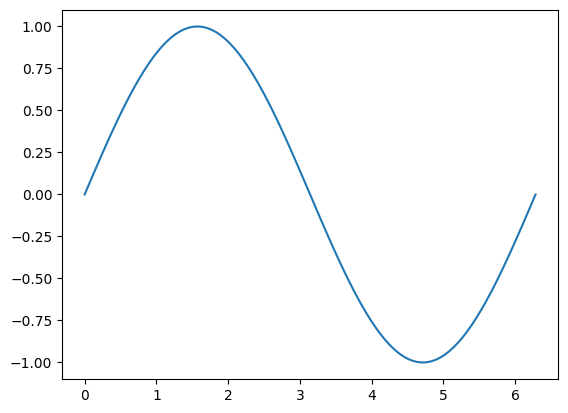

In [ ]:
# TODO: xs = np.linspace(0, 2*np.pi, 100), plt.plot(xs, np.sin(xs)), plt.show()
xs = np.linspace(0, 2 * np.pi, 100)
plt.plot(xs, np.sin(xs))
plt.show()


**Вправа 16.** На одному графіку познач дві групи точок різними кольорами і додай легенду.

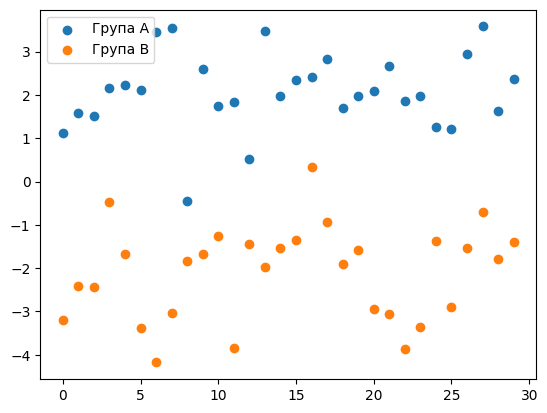

In [ ]:
group_a = np.random.randn(30) + 2
group_b = np.random.randn(30) - 2

# TODO: scatter обох груп різними кольорами (color="C0"/"C1", label=...),
# додати plt.legend(), plt.show()
plt.scatter(range(30), group_a, color="C0", label="Група A")
plt.scatter(range(30), group_b, color="C1", label="Група B")
plt.legend()
plt.show()

---
## Завдання 1. Лінійна регресія

Тренуємо базовий пайплайн на простій лінійній регресії з одним параметром.

$$y = w \cdot x + b + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, 1)$$

In [ ]:
TASK1_TRUE_W = 2.0
TASK1_TRUE_B = 1.0
TASK1_N = 300

x1 = torch.empty(TASK1_N, 1).uniform_(-5, 5)
noise = 1.0 * torch.randn(TASK1_N, 1)
y1 = TASK1_TRUE_W * x1 + TASK1_TRUE_B + noise

**Вправа 17.** Перш ніж будувати модель — подивись на самі дані.

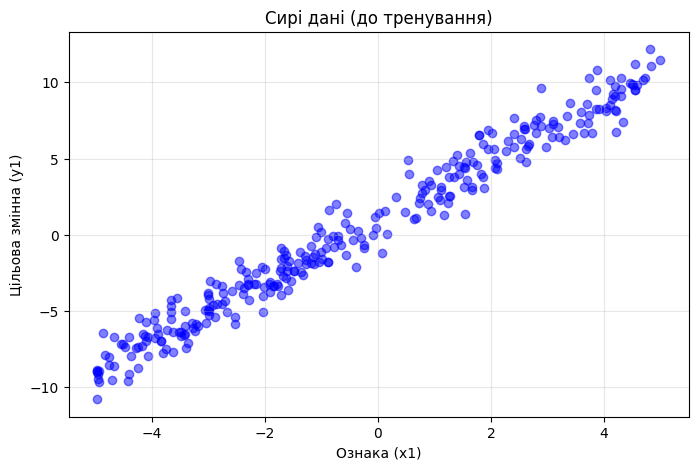

In [ ]:
# TODO: Точкова діаграма (scatter plot) з вісями x1 та y1, підпис осей (xlabel/ylabel), заголовок
# "Сирі дані (до тренування)"
plt.figure(figsize=(8, 5))
plt.scatter(x1.numpy(), y1.numpy(), alpha=0.5, color='blue')
plt.title("Сирі дані (до тренування)")
plt.xlabel("Ознака (x1)")
plt.ylabel("Цільова змінна (y1)")
plt.grid(True, alpha=0.3)
plt.show()

**Вправа 18.** Розбий дані на train/val/test (70/15/15). Перемішай дані перед зрізом, інакше спліт вийде не випадковим.

In [ ]:
# TODO: перемішати x1/y1 через torch.randperm(TASK1_N), розбити на
# train/val/test у пропорції 70/15/15
indices = torch.randperm(TASK1_N)
x1_shuffled = x1[indices]
y1_shuffled = y1[indices]

train_size = int(0.70 * TASK1_N)
val_size = int(0.15 * TASK1_N)

x_train1 = x1_shuffled[:train_size]
y_train1 = y1_shuffled[:train_size]

x_val1 = x1_shuffled[train_size:train_size + val_size]
y_val1 = y1_shuffled[train_size:train_size + val_size]

x_test1 = x1_shuffled[train_size + val_size:]
y_test1 = y1_shuffled[train_size + val_size:]

print(f"train/val/test: {len(x_train1)}/{len(x_val1)}/{len(x_test1)}")

train/val/test: 210/45/45


**Вправа 19.** Нижче — готовий цикл навчання, кожен крок підписаний окремо. Просто запусти обидві комірки й подивись, як модель наближається до `true` за 100 епох (знімки кожні 30 епох).

In [ ]:
task1_model = torch.nn.Linear(in_features=1, out_features=1)
optimizer = torch.optim.SGD(task1_model.parameters(), lr=0.05)
loss_fn = torch.nn.MSELoss()

x_line = torch.linspace(-5, 5, 100).unsqueeze(1)  # сітка для візуалізації лінії
snapshots = []  # (epoch, w, b, y_line_pred) кожні 30 епох

for epoch in range(100):
    # обнулити градієнти з попереднього кроку
    optimizer.zero_grad()
    # forward -- прогноз моделі на поточних w, b
    y_pred = task1_model(x_train1)
    # loss -- наскільки прогноз відрізняється від y_train1
    loss = loss_fn(y_pred, y_train1)
    # backward -- градієнти loss за w і b
    loss.backward()
    # крок оптимізатора -- оновити w і b
    optimizer.step()

    if epoch % 30 == 0 or epoch == 99:
        with torch.no_grad():
            y_line_pred = task1_model(x_line)
        snapshots.append((epoch, task1_model.weight.item(), task1_model.bias.item(), y_line_pred))
        print(f"epoch {epoch:4d}  loss={loss.item():.6f}  "
              f"w={task1_model.weight.item():.4f} (true {TASK1_TRUE_W})  "
              f"b={task1_model.bias.item():.4f} (true {TASK1_TRUE_B})")


epoch    0  loss=10.796704  w=1.7971 (true 2.0)  b=-0.2009 (true 1.0)
epoch   30  loss=1.030498  w=1.9806 (true 2.0)  b=1.0221 (true 1.0)
epoch   60  loss=1.026565  w=1.9829 (true 2.0)  b=1.0764 (true 1.0)
epoch   90  loss=1.026557  w=1.9830 (true 2.0)  b=1.0788 (true 1.0)
epoch   99  loss=1.026557  w=1.9830 (true 2.0)  b=1.0789 (true 1.0)


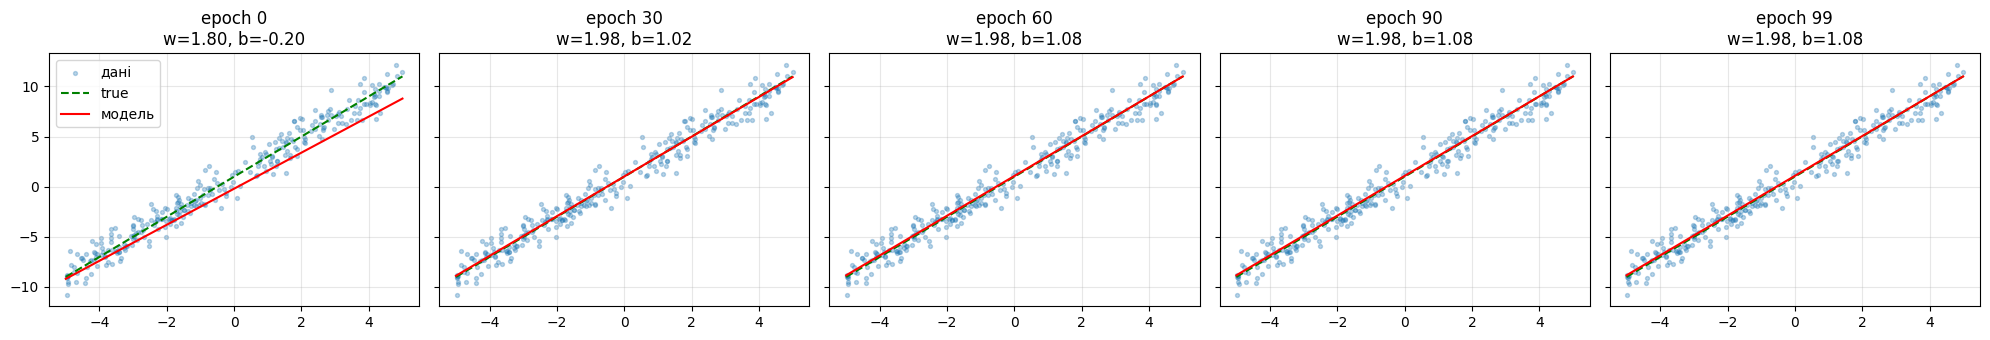

In [ ]:
with torch.no_grad():
    y_line_true = TASK1_TRUE_W * x_line + TASK1_TRUE_B

fig, axes = plt.subplots(1, len(snapshots), figsize=(4 * len(snapshots), 3.5), sharey=True)
for ax, (epoch, w, b, y_line_pred) in zip(axes, snapshots):
    ax.scatter(x1.numpy(), y1.numpy(), s=8, alpha=0.3, label="дані")
    ax.plot(x_line.numpy(), y_line_true.numpy(), "g--", label="true")
    ax.plot(x_line.numpy(), y_line_pred.numpy(), "r-", label="модель")
    ax.set_title(f"epoch {epoch}\nw={w:.2f}, b={b:.2f}")
    ax.grid(alpha=0.3)
axes[0].legend()
plt.tight_layout()
plt.show()


**Вправа 20.** Придумай власний напів-реальний сценарій лінійної залежності
(наприклад: кількість з'їдених пачок чіпсів на тиждень → індекс маси тіла;
години сну → продуктивність; щось своє). У markdown-комірці перед кодом
опиши сценарій: яку залежність ти
закладаєш ($w$, $b$) і чому саме такі значення видались тобі правдоподібними.
Згенеруй дані з шумом, збережи їх у CSV файл (за зразком відповідної частини лекції)
і натренуй лінійну регресію за тим самим патерном — спліт, цикл навчання, перевірка на test.
Організуй код тренування у логічні перевикористовувані функції.

# Сценарій лінійної регресії

**Залежність кількості вивчених іноземних слів користувачем від кількості пройдених інтерактивних уроків у адаптивному веб-додатку.**

Формула лінійної регресії має вигляд:
$$y = w \cdot x + b$$

Де:
* **$x$** — кількість пройдених інтерактивних уроків (незалежна змінна)
* **$y$** — прогнозована кількість вивчених слів (залежна змінна)

### Параметри моделі

* **$w$ (вага) = 8.5**  
  Коефіцієнт ефективності навчання. За алгоритмами платформи, кожен пройдений урок дає в середньому **8.5 закріплених у пам'яті нових слів** (з урахуванням аналізу помилок та інтервальних повторень).
* **$b$ (зсув / bias) = 50.0**  
  Базовий словниковий запас. Передбачається, що користувач при реєстрації в додатку вже знає мінімум **50 базових слів**.

---

###  Приклади розрахунків

| Кількість уроків ($x$) | Формула розрахунку | Прогнозований словниковий запас ($y$) |
| :--- | :--- | :--- |
| **0 уроків** (старт) | $8.5 \cdot 0 + 50.0$ | **50 слів** |
| **10 уроків** | $8.5 \cdot 10 + 50.0$ | **135 слів** |
| **50 уроків** | $8.5 \cdot 50 + 50.0$ | **475 слів** |
| **100 уроків** | $8.5 \cdot 100 + 50.0$ | **900 слів** |


In [36]:
# 1. Генерація даних для мовного додатка
# Користувачі проходять від 5 до 100 уроків
x_lessons = torch.empty(300, 1).uniform_(5, 100)
noise_words = 15.0 * torch.randn(300, 1) # випадковий шум (індивідуальні здібності)

# Формула y = w*x + b (8.5 слів за урок + 50 базових)
y_words = 8.5 * x_lessons + 50.0 + noise_words

# 2. Збереження у CSV
df = pd.DataFrame({'lessons_completed': x_lessons.flatten().numpy(), 'words_learned': y_words.flatten().numpy()})
df.to_csv("dataset.csv", index=False)
print("Дані платформи збережено у dataset.csv")

# 3. Розбиття на train/val/test (70/15/15)
indices = torch.randperm(300)
x_shuffled = x_lessons[indices]
y_shuffled = y_words[indices]

train_idx = int(0.7 * 300)
val_idx = train_idx + int(0.15 * 300)

x_train = x_shuffled[:train_idx]
y_train = y_shuffled[:train_idx]
x_val = x_shuffled[train_idx:val_idx]
y_val = y_shuffled[train_idx:val_idx]
x_test = x_shuffled[val_idx:]
y_test = y_shuffled[val_idx:]

# 4. Просте тренування моделі
my_model = torch.nn.Linear(1, 1)
# Зменшуємо learning rate, оскільки x може бути великим (до 100), щоб градієнт не "вибухнув"
optimizer = torch.optim.SGD(my_model.parameters(), lr=0.0001)
loss_fn = torch.nn.MSELoss()
# 80000 епох дадуть моделі час правильно підібрати не тільки 'w', але й 'b'
for epoch in range(80000):
    optimizer.zero_grad()
    loss = loss_fn(my_model(x_train), y_train)
    loss.backward()
    optimizer.step()

print("\nТренування моделі аналізу завершено!")
print(f"Знайдене w = {my_model.weight.item():.4f} (має бути близько 8.50)")
print(f"Знайдене b = {my_model.bias.item():.4f} (має бути близько 50.0)")

Дані платформи збережено у dataset.csv

Тренування моделі аналізу завершено!
Знайдене w = 8.5109 (має бути близько 8.50)
Знайдене b = 48.3100 (має бути близько 50.0)


**Вправа 21.** Збережи натреновану модель на своєму гугл диску у файлі з назвою `model.pt`.
Збережений файл потрібно буде також здати разом з лабою.

In [39]:
torch.save(my_model.state_dict(), "model.pt")
print("Модель успішно збережена у файл: model.pt")

Модель успішно збережена у файл: model.pt


**Вправа 22.** Встанови [Gradio](https://gradio.app/)
```
!pip install -q gradio
import gradio as gr
```
Завантаж свою модель, збережену в попередній вправі і створи інтерактивну аппку.

In [37]:
# !pip install -q gradio
import gradio as gr

# Завантажуємо нашу збережену модель
loaded_model = torch.nn.Linear(1, 1)
loaded_model.load_state_dict(torch.load("model.pt"))
loaded_model.eval()

# Функція для передбачення
def predict_vocabulary(lessons):
    x_tensor = torch.tensor([[float(lessons)]])
    with torch.no_grad():
        pred = loaded_model(x_tensor).item()

    # Словниковий запас не може бути меншим за базові 50 слів
    return f"Прогнозований словниковий запас: {max(50, int(pred))} слів"

# Створюємо інтерфейс
app = gr.Interface(
    fn=predict_vocabulary,
    inputs=gr.Number(label="Кількість пройдених уроків у додатку", value=10),
    outputs=gr.Textbox(label="Прогноз успішності"),
    title="Адаптивна модель прогнозування прогресу",
    description="Введіть кількість пройдених уроків, щоб оцінити загальний обсяг вивченої лексики користувача."
)

app.launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://61e540f1b195a85dcb.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://273422966d182e31af.gradio.live
Killing tunnel 127.0.0.1:7860 <> https://61e540f1b195a85dcb.gradio.live


---
### Як здавати лабу
У [форму](https://forms.gle/5qxRYshxKknBXDCz8) здати посилання на **публічний** репозиторій, який містить:
1. **Цей ноутбук з усіма виконаними вправами**. Ноутбук має запускатися зверху до низу (Run All) в будь-якому середовищі без помилок.
2. **Додаткові скріншоти** по ходу виконання лаби (якими Ви доводите, що справді виконували цбю лабу).
3. Створений по ходу виконання лаби **csv файл** з даними і **pt файл** з моделлю.
4. Структура файлів на репозиторії, **точно дотримуйтесь, інакше не зарахується лаба**:
```
    /lab1/linear_models_lab.ipynb
    /lab1/screenshots/*
    /lab1/dataset.csv
    /lab1/model.pt
```